In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 47.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.7 MB/s eta 0:00:0000:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 76.7 MB/s eta 0:00:00:00:0100:01


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pennylane as qml
from tqdm import tqdm
import math

In [3]:
# %% [code]
# ===============================
# DATASET + DATALOADERS
# ===============================

import os, glob
import numpy as np
from typing import Tuple
import torch
from torch.utils.data import Dataset, DataLoader

class UAVHSICropDataset(Dataset):
    def __init__(self, root_dir: str, split: str = "Training"):
        if split in ["Training", "Validation"]:
            base = os.path.join(root_dir, split)
        elif split == "Test":
            base = root_dir
        else:
            raise ValueError("split must be Training, Validation or Test")
        self.rs_dir = os.path.join(base, "rs")
        self.gt_dir = os.path.join(base, "gt")
        self.rs_files = sorted(glob.glob(os.path.join(self.rs_dir, "*.npy")))
        self.gt_files = sorted(glob.glob(os.path.join(self.gt_dir, "*.npy")))
        assert len(self.rs_files) == len(self.gt_files), "rs/gt count mismatch"

    def __len__(self):
        return len(self.rs_files)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        rs = np.load(self.rs_files[idx])
        gt = np.load(self.gt_files[idx])
        rs = torch.from_numpy(rs).float().permute(2,0,1)  # (C,H,W)
        gt = torch.from_numpy(gt).long()                  # (H,W)
        return rs, gt

def make_loaders(root_train, root_test, batch_size=8, num_workers=2):
    train_ds = UAVHSICropDataset(root_train, "Training")
    val_ds   = UAVHSICropDataset(root_train, "Validation")
    test_ds  = UAVHSICropDataset(root_test,  "Test")
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader


In [4]:
# %% [code]
# ===============================
# PATCHGRAPH + HYBRID QUANTUM MODEL
# ===============================

import torch, torch.nn as nn, torch.nn.functional as F
import pennylane as qml
import math

# ---------- Patch Embedding ----------
class PatchEmbed(nn.Module):
    def __init__(self, in_channels=200, patch_size=6, embed_dim=192, img_size=96):
        super().__init__()
        self.grid_h = img_size // patch_size
        self.grid_w = img_size // patch_size
        self.num_patches = self.grid_h * self.grid_w
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        return x + self.pos_embed

# ---------- Grid adjacency ----------
def make_grid_edges(grid_h, grid_w, device):
    N = grid_h * grid_w
    adj = torch.zeros(N,N,device=device)
    def idx(i,j): return i*grid_w+j
    for i in range(grid_h):
        for j in range(grid_w):
            u = idx(i,j)
            for di,dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni,nj = i+di, j+dj
                if 0<=ni<grid_h and 0<=nj<grid_w:
                    adj[u, idx(ni,nj)] = 1.0
    adj.fill_diagonal_(1.0)
    adj = adj / adj.sum(1, keepdim=True)
    return adj

# ---------- Graph Attention ----------
class GraphAttention(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.qkv = nn.Linear(dim, dim*3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x, adj):
        B,N,D = x.shape
        qkv = self.qkv(x).reshape(B,N,3,self.num_heads,self.head_dim).permute(2,0,3,1,4)
        q,k,v = qkv
        attn = (q @ k.transpose(-2,-1)) / math.sqrt(self.head_dim)
        mask = (adj==0).unsqueeze(0).unsqueeze(0)
        attn = attn.masked_fill(mask, -1e9)
        attn = F.softmax(attn, dim=-1)
        out = attn @ v
        out = out.transpose(1,2).reshape(B,N,D)
        return self.proj(out)

class GraphTransformerBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = GraphAttention(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim*4), nn.GELU(), nn.Linear(dim*4, dim))

    def forward(self, x, adj):
        x = x + self.attn(self.norm1(x), adj)
        x = x + self.mlp(self.norm2(x))
        return x

# ---------- Classical Head ----------
class ClassicalPatchHead(nn.Module):
    def __init__(self, embed_dim=192, num_classes=30):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(embed_dim, 256), nn.ReLU(), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.net(x)

# ---------- Quantum Global Head ----------
class QuantumGlobalHead(nn.Module):
    def __init__(self, embed_dim=192, num_classes=30, n_qubits=4):
        super().__init__()
        self.reduce = nn.Linear(embed_dim, n_qubits)
        dev = qml.device("default.qubit", wires=n_qubits)
        @qml.qnode(dev, interface="torch")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits))
            qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
        self.qlayer = qml.qnn.TorchLayer(circuit, weight_shapes={"weights":(2,n_qubits)})
        self.fc = nn.Linear(n_qubits, num_classes)
    def forward(self, x):
        x = torch.tanh(self.reduce(x))
        x = self.qlayer(x)
        return self.fc(x)

# ---------- Full Hybrid Model ----------
class PatchGraphHybridQuantum(nn.Module):
    def __init__(self, num_classes=30, alpha=0.2, in_channels=200, img_size=96, patch_size=6, embed_dim=192, depth=6):
        super().__init__()
        self.alpha = alpha
        self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
        Gh = Gw = img_size // patch_size
        self.blocks = nn.ModuleList([GraphTransformerBlock(embed_dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.classical_head = ClassicalPatchHead(embed_dim, num_classes)
        self.quantum_head = QuantumGlobalHead(embed_dim, num_classes)
        self.Gh, self.Gw = Gh, Gw

    def forward(self, x, output_size):
        device = x.device
        adj = make_grid_edges(self.Gh, self.Gw, device)
        x = self.patch_embed(x)
        for blk in self.blocks:
            x = blk(x, adj)
        x = self.norm(x)
        logits_c = self.classical_head(x)      # (B,N,C)

        global_token = x.mean(dim=1)           # (B,D)
        logits_q = self.quantum_head(global_token)   # (B,C)
        logits_q_exp = logits_q.unsqueeze(1).expand_as(logits_c)
        logits = logits_c + self.alpha*logits_q_exp

        B,N,C = logits.shape
        logits = logits.transpose(1,2).reshape(B,C,self.Gh,self.Gw)
        return F.interpolate(logits,size=output_size,mode="bilinear",align_corners=False)


In [14]:
# %% [code]
# ===============================
# HYBRID CE + LOG-COSH DICE LOSS
# ===============================

import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridCELoss_LogCoshDice(nn.Module):
    def __init__(self, num_classes=30, alpha=0.5, class_weights=None, eps=1e-5):
        super().__init__()
        self.alpha = alpha
        self.num_classes = num_classes
        self.eps = eps
        if class_weights is not None:
            self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)
        else:
            self.ce_loss = nn.CrossEntropyLoss()
    
    def forward(self, logits, target):
        # Cross-entropy part (weighted)
        ce = self.ce_loss(logits, target)
        
        # Log-Cosh Dice part
        # logits: (B,C,H,W), target: (B,H,W)
        pred = F.softmax(logits, dim=1)
        target_onehot = F.one_hot(target, num_classes=self.num_classes)  # (B,H,W,C)
        target_onehot = target_onehot.permute(0,3,1,2).float()  # (B,C,H,W)
        
        intersect = (pred * target_onehot).sum(dim=(0,2,3))
        union = pred.sum(dim=(0,2,3)) + target_onehot.sum(dim=(0,2,3))
        dice = 1 - (2*intersect + self.eps) / (union + self.eps)
        log_cosh_dice = torch.log(torch.cosh(dice)).mean()
        
        # Hybrid loss
        loss = (1 - self.alpha)*ce + self.alpha*log_cosh_dice
        return loss


In [15]:
# %% [code]
# ===============================
# TRAINING / EVAL / METRICS
# ===============================

import torch
from torch.optim import AdamW
import numpy as np
from sklearn.metrics import confusion_matrix

def train_one_epoch(model, loader, optimizer, criterion, device, alpha=0.2):
    model.train()
    model.alpha = alpha
    total_loss = 0
    for rs, gt in loader:
        rs, gt = rs.to(device), gt.to(device)
        optimizer.zero_grad()
        logits = model(rs, gt.shape[-2:])  # PatchGraphHybridQuantum forward expects img, spatial size
        loss = criterion(logits, gt)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * rs.size(0)
    return total_loss / len(loader.dataset)

def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0,0,0
    with torch.no_grad():
        for rs, gt in loader:
            rs, gt = rs.to(device), gt.to(device)
            logits = model(rs, gt.shape[-2:])
            loss = criterion(logits, gt)
            total_loss += loss.item() * rs.size(0)
            preds = logits.argmax(1)
            correct += (preds==gt).sum().item()
            total += gt.numel()
    return total_loss / len(loader.dataset), correct/total

def compute_confusion_matrix(model, loader, device, num_classes=30):
    model.eval()
    all_preds, all_gts = [], []
    with torch.no_grad():
        for rs, gt in loader:
            rs, gt = rs.to(device), gt.to(device)
            logits = model(rs, gt.shape[-2:])
            preds = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds.ravel())
            all_gts.extend(gt.cpu().numpy().ravel())
    cm = confusion_matrix(all_gts, all_preds, labels=range(num_classes))
    return cm

def compute_metrics(cm):
    oa = np.trace(cm)/np.sum(cm)
    aa = np.mean(np.diag(cm)/(cm.sum(1)+1e-8))
    pe = np.sum(cm.sum(0)*cm.sum(1))/np.sum(cm)**2
    kappa = (oa-pe)/(1-pe+1e-8)
    miou = np.mean(np.diag(cm)/(cm.sum(1)+cm.sum(0)-np.diag(cm)+1e-8))
    return oa, aa, kappa, miou


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Epoch 1 | alpha=0.007
Train Loss: 1.5786 | Val Loss: 1.4951 | Val OA: 50.56%
Saved best model.

Epoch 2 | alpha=0.013
Train Loss: 1.3470 | Val Loss: 1.4021 | Val OA: 51.29%
Saved best model.

Epoch 3 | alpha=0.020
Train Loss: 1.2560 | Val Loss: 1.3728 | Val OA: 55.55%
Saved best model.

Epoch 4 | alpha=0.027
Train Loss: 1.1801 | Val Loss: 1.2404 | Val OA: 58.26%
Saved best model.

Epoch 5 | alpha=0.033
Train Loss: 1.1310 | Val Loss: 1.2028 | Val OA: 60.14%
Saved best model.

Epoch 6 | alpha=0.040
Train Loss: 1.1194 | Val Loss: 1.1965 | Val OA: 61.82%
Saved best model.

Epoch 7 | alpha=0.047
Train Loss: 1.0708 | Val Loss: 1.1804 | Val OA: 58.83%
Saved best model.

Epoch 8 | alpha=0.053
Train Loss: 1.0429 | Val Loss: 1.0965 | Val OA: 63.80%
Saved best model.

Epoch 9 | alpha=0.060
Train Loss: 1.0501 | Val Loss: 1.0821 | Val OA: 64.33%
Saved best model.

Epoch 10 | alpha=0.067
Train Loss: 1.0233 | Val Loss: 1.0634 | Val OA: 66.08%
Saved best model.

Epoch 11 | alpha=0.073
Train Loss: 0.9

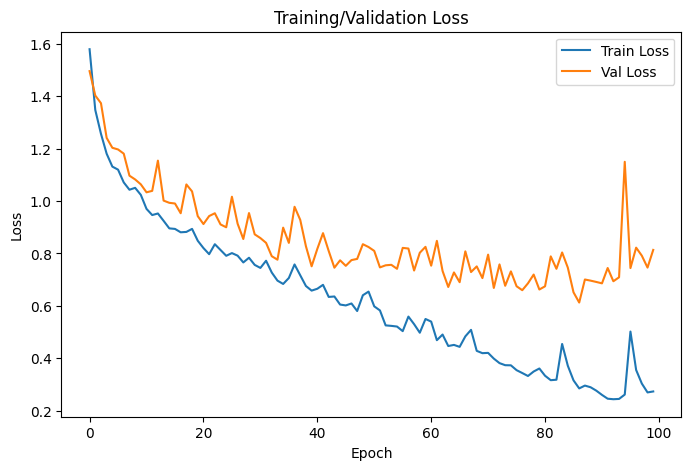

In [16]:
# %% [code]
# ===============================
# MAIN TRAINING LOOP
# ===============================

import matplotlib.pyplot as plt
import torch
from torch.optim import AdamW

def main():
    root_train = "/kaggle/input/uav-hsi/Train"
    root_test  = "/kaggle/input/uav-hsi/Test"

    train_loader, val_loader, test_loader = make_loaders(root_train, root_test, batch_size=8, num_workers=2)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PatchGraphHybridQuantum(num_classes=30, alpha=0.0).to(device)

    # Compute class weights from training GT
    all_gts = []
    for _, gt in train_loader:
        all_gts.append(gt.numpy().ravel())
    all_gts = np.concatenate(all_gts)
    class_counts = np.bincount(all_gts, minlength=30)
    class_weights = 1.0 / np.sqrt(class_counts + 1e-6)  # inverse sqrt frequency
    class_weights = torch.tensor(class_weights, device=device, dtype=torch.float32)

    # Use Hybrid Loss
    criterion = HybridCELoss_LogCoshDice(num_classes=30, alpha=0.5, class_weights=class_weights)

    optimizer = AdamW([
        {"params": model.patch_embed.parameters()},
        {"params": model.blocks.parameters()},
        {"params": model.classical_head.parameters()},
        {"params": model.quantum_head.parameters(), "lr": 5e-5},
    ], lr=3e-4, weight_decay=1e-4)

    best_val = float("inf")
    train_losses, val_losses, val_oa_list = [],[],[]

    num_epochs = 100
    for epoch in range(1, num_epochs + 1):
        alpha = min(0.2, epoch/30*0.2)  # alpha schedule
        print(f"\nEpoch {epoch} | alpha={alpha:.3f}")

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, alpha)
        val_loss, val_oa = eval_one_epoch(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_oa_list.append(val_oa)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val OA: {val_oa*100:.2f}%")
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "patchgraph_hybrid_quantum_best.pth")
            print("Saved best model.")

    # final evaluation
    model.load_state_dict(torch.load("patchgraph_hybrid_quantum_best.pth", map_location=device))
    test_loss, test_oa = eval_one_epoch(model, test_loader, criterion, device)
    print(f"\nTest Loss: {test_loss:.4f} | Test OA: {test_oa*100:.2f}%")

    cm = compute_confusion_matrix(model, test_loader, device)
    oa, aa, kappa, miou = compute_metrics(cm)
    print(f"OA: {oa*100:.2f}%, AA: {aa*100:.2f}%, Kappa: {kappa:.4f}, mIoU: {miou:.4f}")

    # plot train/val curve
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training/Validation Loss")
    plt.legend()
    plt.show()

if __name__=="__main__":
    main()
